# LeetCode #123: Best Time to Buy and Sell Stock III

https://leetcode.com/problems/best-time-to-buy-and-sell-stock-iii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| DP 2D table (general k) | O(n) | O(n) | General k-transaction DP |
| **DP 4 State Variables** | **O(n)** | **O(1)** | **Optimal — specialized for k=2** |

## Understanding the Method

Track 4 state variables updated each day:
- `buy1` = max profit after first purchase (maximize by buying at lowest)
- `sell1` = max profit after first sale
- `buy2` = max profit after second purchase (deduct from sell1)
- `sell2` = max profit after second sale (answer)

## Constraints

- `1 <= prices.length <= 10^5`
- `0 <= prices[i] <= 10^5`

## Solutions

### C#

In [ ]:
public class Solution {
    public int MaxProfit(int[] prices) {
        int buy1 = int.MinValue, sell1 = 0, buy2 = int.MinValue, sell2 = 0;
        foreach (int p in prices) {
            buy1  = Math.Max(buy1,  -p);
            sell1 = Math.Max(sell1, buy1 + p);
            buy2  = Math.Max(buy2,  sell1 - p);
            sell2 = Math.Max(sell2, buy2 + p);
        }
        return sell2;
    }
}

### Python

In [ ]:
class Solution:
    def maxProfit(self, prices: list[int]) -> int:
        buy1 = buy2 = float('-inf')
        sell1 = sell2 = 0
        for p in prices:
            buy1  = max(buy1,  -p)
            sell1 = max(sell1, buy1 + p)
            buy2  = max(buy2,  sell1 - p)
            sell2 = max(sell2, buy2 + p)
        return sell2

### Go

In [ ]:
import "math"

func maxProfit(prices []int) int {
    buy1, sell1 := math.MinInt32, 0
    buy2, sell2 := math.MinInt32, 0
    for _, p := range prices {
        if -p > buy1 { buy1 = -p }
        if buy1+p > sell1 { sell1 = buy1 + p }
        if sell1-p > buy2 { buy2 = sell1 - p }
        if buy2+p > sell2 { sell2 = buy2 + p }
    }
    return sell2
}

### Rust

In [ ]:
impl Solution {
    pub fn max_profit(prices: Vec<i32>) -> i32 {
        let (mut buy1, mut sell1, mut buy2, mut sell2) = (i32::MIN, 0, i32::MIN, 0);
        for p in prices {
            buy1  = buy1.max(-p);
            sell1 = sell1.max(buy1 + p);
            buy2  = buy2.max(sell1 - p);
            sell2 = sell2.max(buy2 + p);
        }
        sell2
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `prices = [3, 3, 5, 0, 0, 3, 1, 4]`  
Two optimal trades: buy@0 sell@3 $(+3)$; buy@1 sell@4 $(+3)$. Total $= 6$. Track 4 states: `buy1, sell1, buy2, sell2` updated each day.  
WHY tricky: Two non-overlapping trades required. The 4-variable approach chains `sell1` into `buy2`. LaTeX: $\text{sell2} = \max(\text{sell2},\, \text{buy2} + p)$.

### 2. Slightly Complex -- One Trade Optimal
**Input:** `prices = [1, 2, 3, 4, 5]`  
Monotonically increasing: best single trade $= 5 - 1 = 4$. Second trade adds nothing. `sell2 = sell1 = 4` since `buy2` can only match `sell1`'s profit.  
WHY tricky: Algorithm allows at most 2 trades but correctly degrades to 1 when optimal. No forced second trade. LaTeX: $k \le 2$, but $k = 1$ suffices here.

### 3. Edge Case: Time Factor
**Input:** `prices = [0, 100000, 0, 100000, 0, ...]` ($n = 10^5$ elements)  
Single $O(n)$ pass with 4 variable updates per step $= 4 \times 10^5$ total operations. No nested loops. Optimal: buy@0 sell@100000 twice $= 200{,}000$.  
WHY tricky: At max $n$, verifies $O(n)$ single-pass efficiency. LaTeX: $T(n) = 4n = 4 \times 10^5$ operations.

### 4. Edge Case: Space Factor
**Input:** `prices` of length $10^5$  
Only 4 integer variables regardless of input size. General $k$-transaction DP needs $O(k \times n)$. The specialized $k=2$ solution is $O(1)$ space.  
WHY tricky: Exploits $k=2$ constraint to collapse DP table into 4 scalars. LaTeX: $O(k \cdot n) \to O(1)$ when $k$ is fixed at 2.

### 5. Almost-Impossible but Plausible
**Input:** `prices = [100000, 100000, ..., 100000]` ($10^5$ elements, all identical at max value)  
Every diff $= 0$. `buy1` stays at $-100{,}000$, `sell1` stays at $0$, `sell2` stays at $0$. No profitable trade exists.  
WHY tricky: Flat prices at max value. Verifies no false positive from initialization. LaTeX: $\text{sell2} = 0$ since $\forall i: p_i = p_{i-1}$.

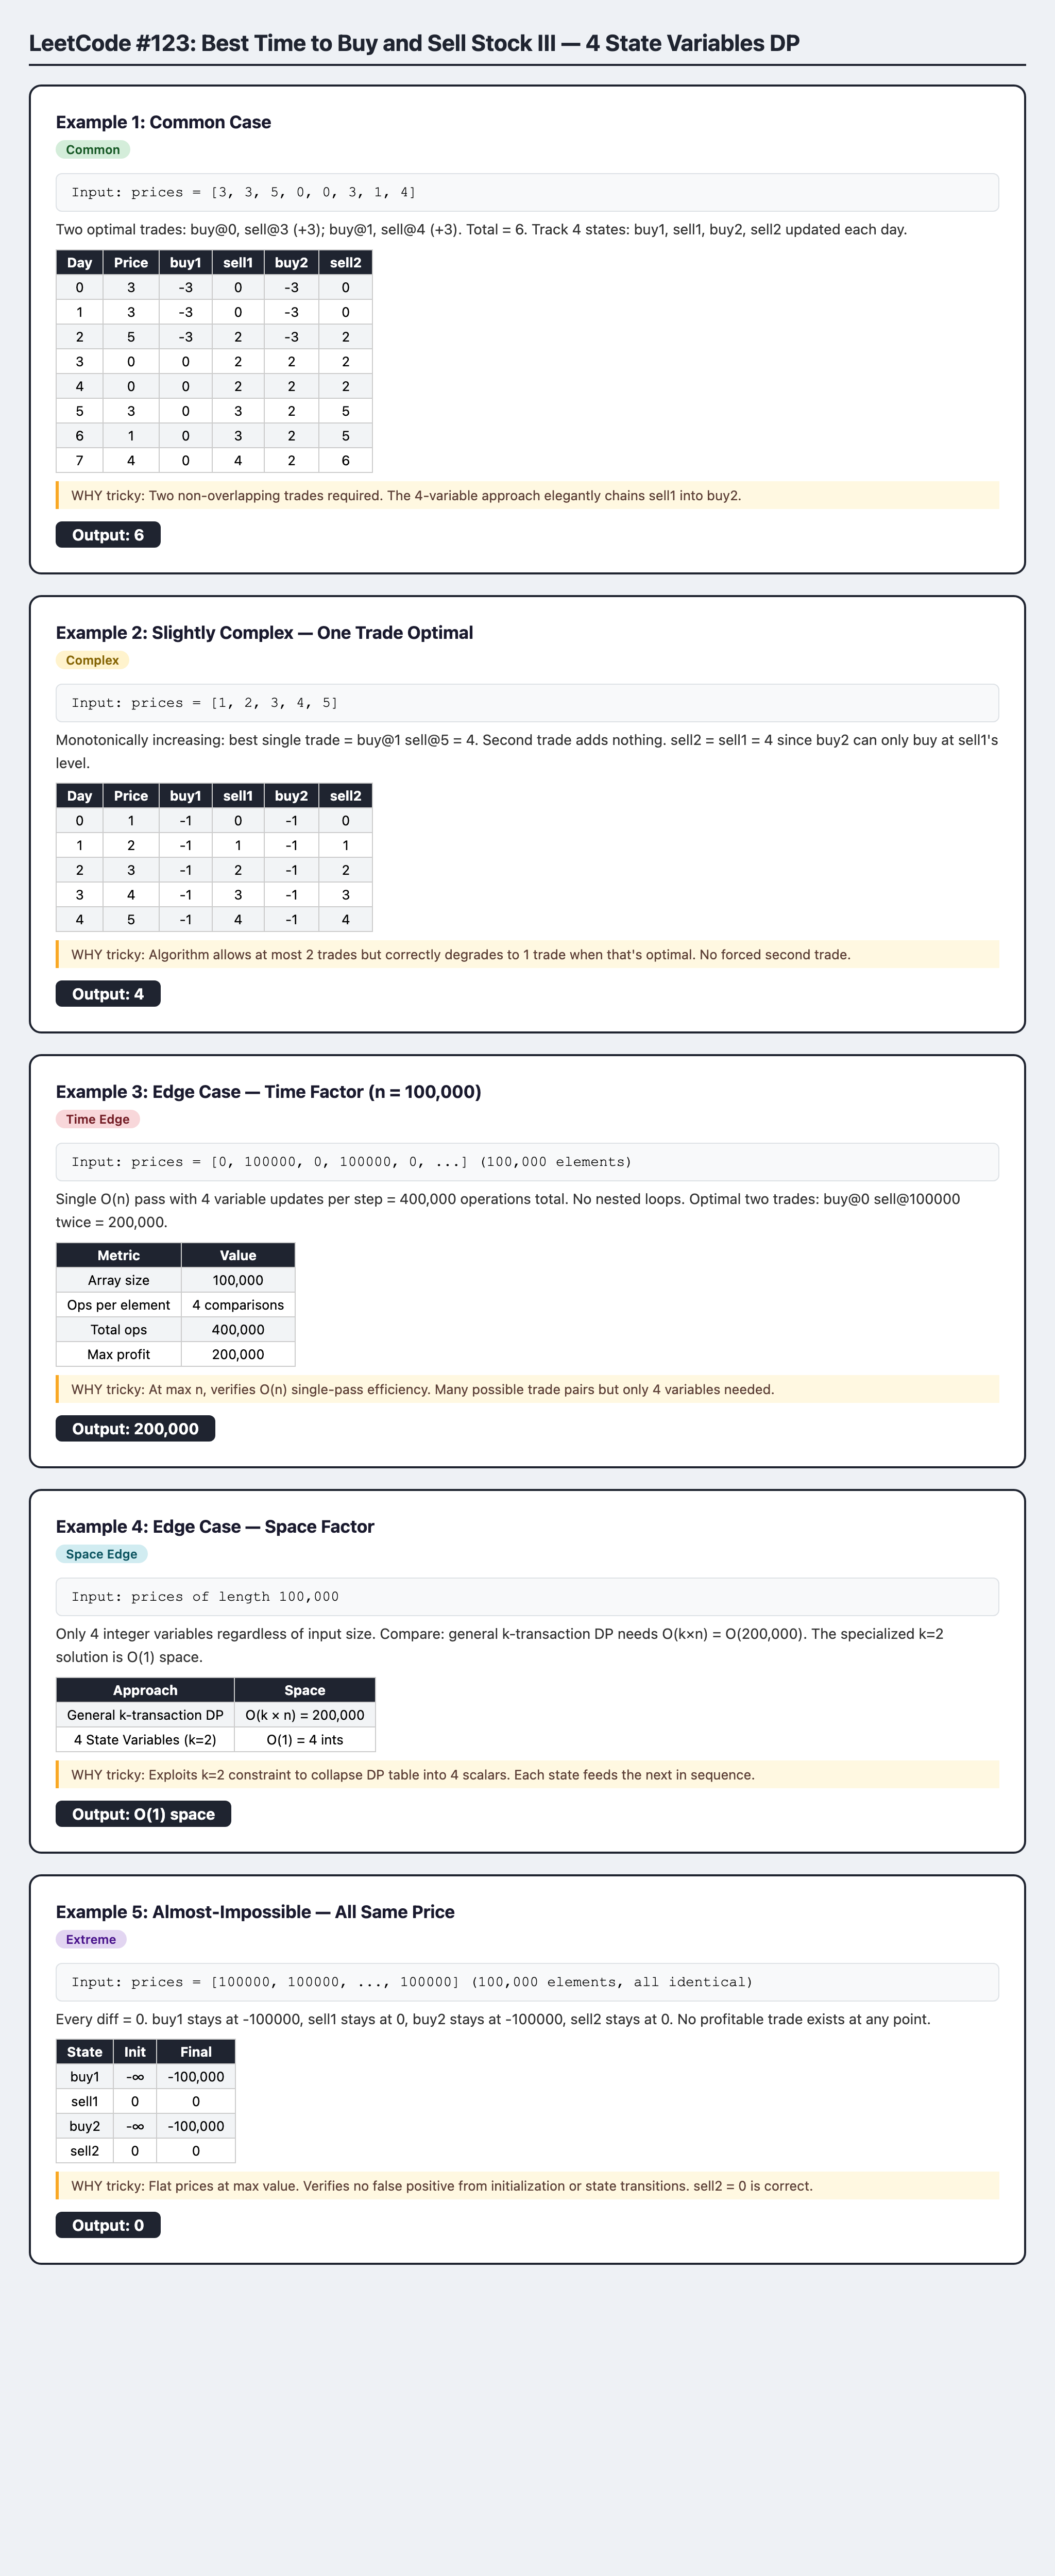